In [25]:
from pandas import DataFrame,read_csv,Series
from numpy import nan
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV,train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score,ConfusionMatrixDisplay,RocCurveDisplay
import warnings
warnings.filterwarnings("ignore")

import joblib

In [3]:
df = read_csv("data/heart.csv")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.shape

(1025, 14)

In [9]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(723)

In [11]:
df.drop_duplicates(inplace=True)
df.shape

(302, 14)

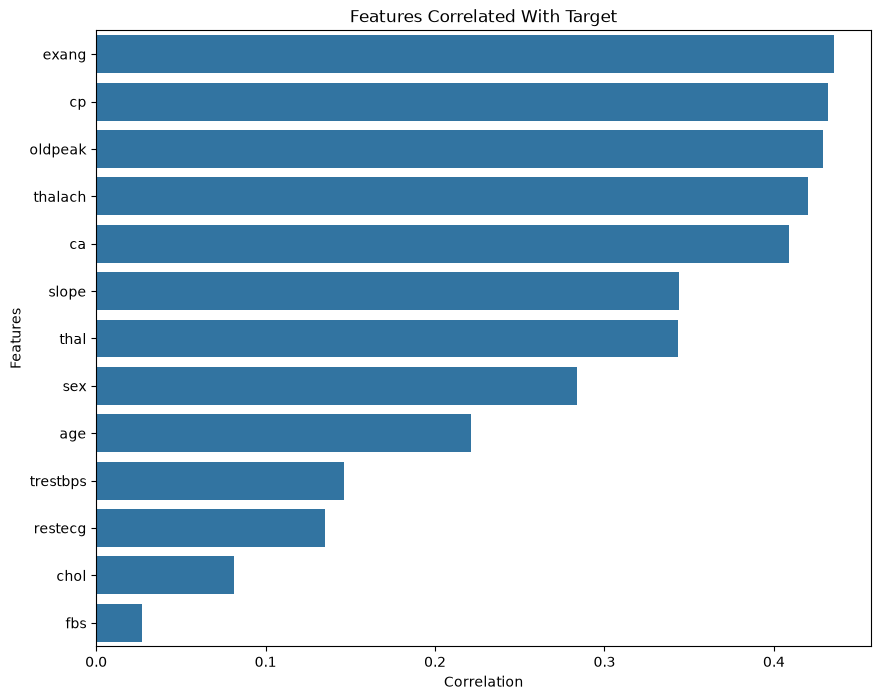

In [12]:
plt.figure(figsize=(10, 8))

corr = (df.corr(numeric_only=True)["target"].drop("target").abs().sort_values(ascending=False))

sns.barplot(x=corr.values,y=corr.index)

plt.title("Features Correlated With Target")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.savefig(f"images/Absolute_Corralation.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

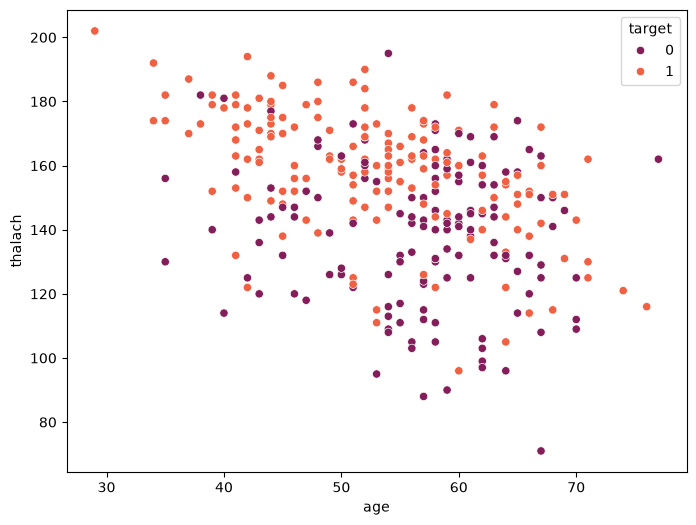

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(df,x="age",y="thalach",hue="target",palette="rocket")
plt.savefig(f"images/scatterplot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

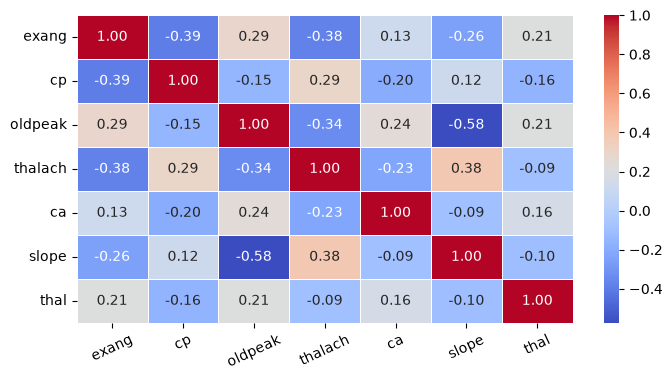

In [14]:
df_corr = df[["exang","cp","oldpeak","thalach","ca","slope","thal"]]
plt.figure(figsize=(8,4))
sns.heatmap(df_corr.corr(),fmt=".2f",cmap="coolwarm",linewidths=0.5,annot=True)

plt.xticks(rotation=25)
plt.savefig(f"images/HeatMap.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

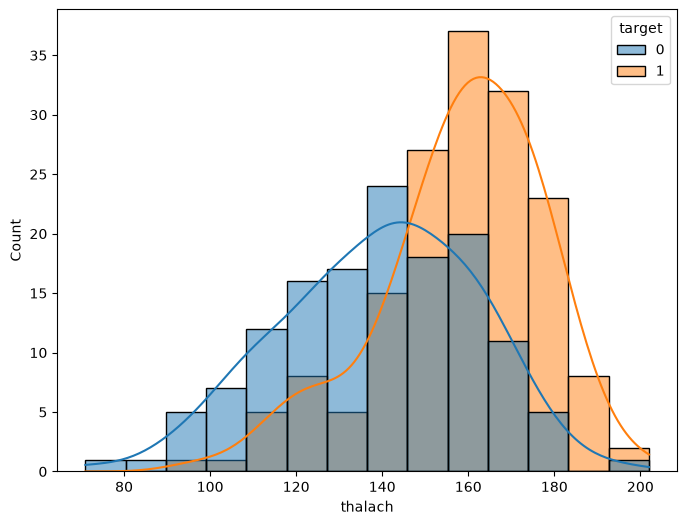

In [15]:
plt.figure(figsize=(8,6))
sns.histplot(df,x="thalach",hue="target",kde=True)
plt.savefig(f"images/Histplot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

target
1    164
0    138
Name: count, dtype: int64


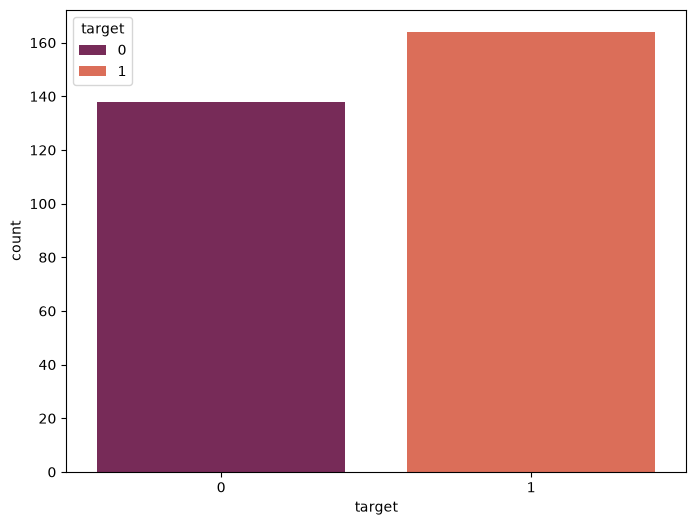

In [16]:
print(df["target"].value_counts())
plt.figure(figsize=(8,6))
sns.countplot(df,x="target",palette="rocket",hue="target")
plt.savefig(f"images/scatterplot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [17]:
df[["trestbps", "chol", "thalach"]]=df[["trestbps", "chol", "thalach"]].replace(0,nan)

X,y =df.drop("target",axis=1),df["target"]

x_train,x_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=3)

In [18]:
pipe = Pipeline([("impute",SimpleImputer(strategy="median")),("scaler",StandardScaler()),("model",LogisticRegression())])

In [19]:
param = [
    {
        "scaler":[StandardScaler(),RobustScaler()],
        "model": [LogisticRegression(random_state=42)],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l1", "l2"],
        "model__solver": ["liblinear", "saga"],
        "model__max_iter": [500, 1000]
    },

    {
        "scaler":["passthrough"],
        "model": [RandomForestClassifier(random_state=42)],
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    },

    {
        "scaler":["passthrough"],
        "model": [GradientBoostingClassifier(random_state=42)],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 5],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2, 4]
    },

    {
        "scaler":["passthrough"],
        "model": [XGBClassifier()],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__min_child_weight": [1, 3, 5],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
]

In [20]:
grid = RandomizedSearchCV(pipe,param,n_iter=75,cv=5,scoring="accuracy",n_jobs=-1,verbose=1,random_state=42) 

In [21]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 75 candidates, totalling 375 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.01, 0.1, ...], 'model__max_iter': [500, 1000], 'model__penalty': ['l1', 'l2'], ...}, {'model': [RandomForestC...ndom_state=42)], 'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], ...}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",75
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find 

In [22]:
best = grid.best_estimator_

print(grid.best_score_)
print(grid.best_params_)
print(grid.best_estimator_)

y_pred = best.predict(x_test)
y_prob = best.predict_proba(x_test)[:,1]

ac = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
pr = precision_score(y_test,y_pred)
re = recall_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_prob)

p = {
    "accuracy_score":ac*100,
    "f1_score":f1*100,
    "precision_score":pr*100,
    "recall_score":re*100,
    "roc_auc_score":roc*100
}

p = DataFrame(p,index=[""])
p

0.8255952380952382
{'scaler': 'passthrough', 'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model': RandomForestClassifier(random_state=42)}
Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scaler', 'passthrough'),
                ('model',
                 RandomForestClassifier(max_depth=20, min_samples_leaf=4,
                                        min_samples_split=10, n_estimators=300,
                                        random_state=42))])


,accuracy_score,f1_score,precision_score,recall_score,roc_auc_score
,85.245902,86.567164,80.555556,93.548387,91.827957


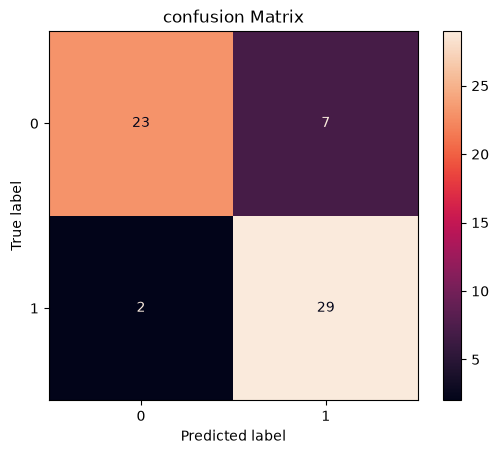

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="rocket")

plt.title("confusion Matrix")
plt.savefig(f"images/Confusion_Matrix.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

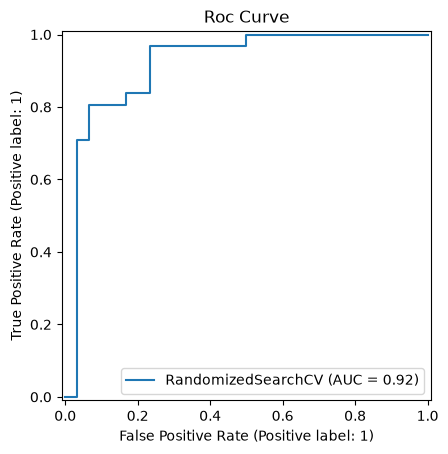

In [24]:
RocCurveDisplay.from_estimator(grid,x_test,y_test)

plt.title("Roc Curve")
plt.savefig(f"images/Roc_Curve.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [26]:
joblib.dump(grid.best_estimator_,"models/Heart_model.joblib")
print("model saved")

model saved
